# Pre-processing and Modeling Notebook

This notebook implements the full time-series modeling workflow for forecasting healthcare call demand and includes the following:

1. Loading and validating the cleaned dataset  
2. Engineering time-series features  
3. Defining expanding-window validation and held-out test splits  
4. Evaluating baseline models (Seasonal Naive and ETS) using one-step-ahead forecasts  
5. Comparing multiple SARIMA-family models using expanding-window cross-validation  
6. Selecting the best-performing model based on validation metrics  
7. Refitting the final model on all pre-test data  
8. Evaluating performance on a held-out test set  
9. Saving results for reporting and reproducibility  

In [1]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
# Paths
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "call_data_cleaned.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

PosixPath('/Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/data/processed/call_data_cleaned.csv')

## 1. Load and Validate Input Data

In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], index_col="Date")

df = df.sort_index()
df.index = pd.DatetimeIndex(df.index, freq="MS")

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
display(df.head())


Shape: (107, 6)
Date range: 2016-04-01 to 2025-02-01


,total_calls,total_doctor_consults,health_info,ambulance_info,complaints,service_info
Date,,,,,,
2016-04-01,51432,43885,3175,220,77,4075
2016-05-01,166635,137326,12118,925,439,15827
2016-06-01,186433,152580,14887,856,473,17637
2016-07-01,145061,116686,11831,922,404,15218
2016-08-01,142400,112831,12184,980,340,16065


In [4]:
# Basic quality checks
missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_index = df.index.duplicated().sum()

print("Missing values by column:")
display(missing_summary.to_frame("missing_count"))
print(f"Duplicate timestamps: {duplicate_index}")

Missing values by column:


,missing_count
total_calls,0
total_doctor_consults,0
health_info,0
ambulance_info,0
complaints,0
service_info,0


Duplicate timestamps: 0


## 2. Pre-processing and Feature Engineering

In [5]:
model_df = df.copy()

RAW_TARGET = "total_calls"
LOG_TARGET = "log_total_calls"

# Target transformations and structural-break indicator
model_df[LOG_TARGET] = np.log1p(model_df[RAW_TARGET])
model_df["covid_period"] = (model_df.index >= pd.Timestamp("2020-03-01")).astype(int)

# Cyclical month encoding for optional downstream models
month_num = model_df.index.month
model_df["month_sin"] = np.sin(2 * np.pi * month_num / 12)
model_df["month_cos"] = np.cos(2 * np.pi * month_num / 12)

display(model_df[[RAW_TARGET, LOG_TARGET, "covid_period", "month_sin", "month_cos"]].head())

,total_calls,log_total_calls,covid_period,month_sin,month_cos
Date,,,,,
2016-04-01,51432,10.848035,0,8.660254e-01,-0.500000
2016-05-01,166635,12.023567,0,5.000000e-01,-0.866025
2016-06-01,186433,12.135833,0,1.224647e-16,-1.000000
2016-07-01,145061,11.884917,0,-5.000000e-01,-0.866025
2016-08-01,142400,11.866402,0,-8.660254e-01,-0.500000


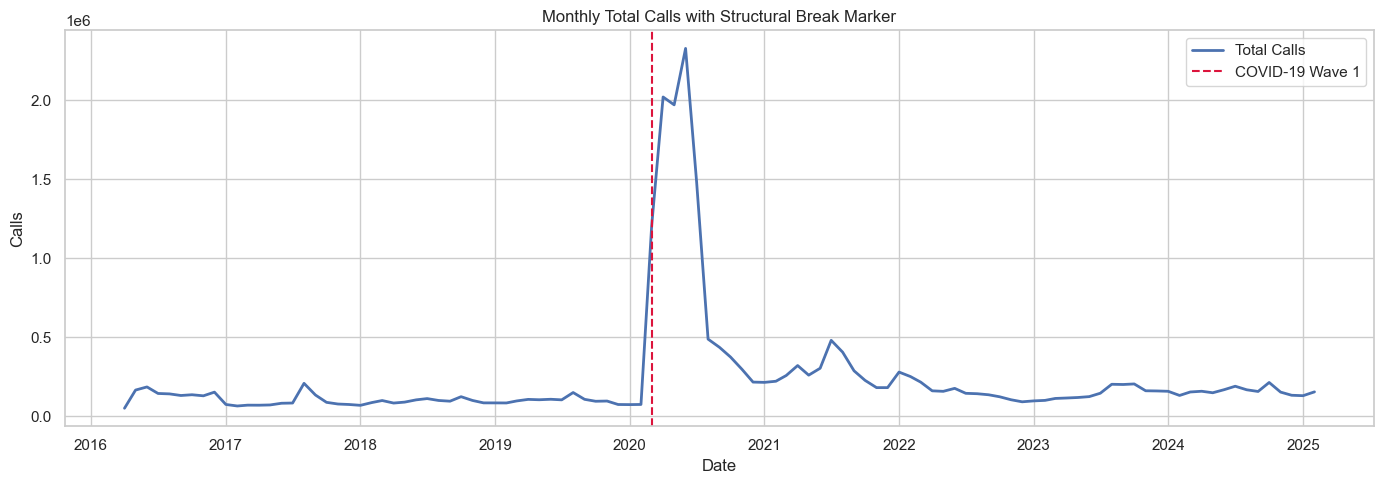

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(model_df.index, model_df[RAW_TARGET], label="Total Calls", linewidth=2)
ax.axvline(pd.Timestamp("2020-03-01"), color="crimson", linestyle="--", label="COVID-19 Wave 1")
ax.set_title("Monthly Total Calls with Structural Break Marker")
ax.set_xlabel("Date")
ax.set_ylabel("Calls")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Expanding-Window Evaluation Setup

Model selection uses a fixed-origin expanding window across the evaluation period.
At each step, the training window grows by one month and each model produces a one-step-ahead forecast.
This yields 24 evaluation points, all in the post-COVID regime, with no leakage.

- **Evaluation window:** 2022-01 to 2023-12 (24 one-step-ahead forecasts)
- **Held-out test:** 2024-01 to 2025-02 (14 months — never touched during model selection)

In [7]:
# Evaluation and test window boundaries
eval_start = pd.Timestamp("2022-01-01")
eval_end   = pd.Timestamp("2023-12-01")
test_start = pd.Timestamp("2024-01-01")

# Choose target for modeling
USE_LOG_TARGET = True  # True = model log_total_calls; False = model raw total_calls

target_col = LOG_TARGET if USE_LOG_TARGET else RAW_TARGET
y = model_df[target_col].copy()

# Keep raw target for evaluation/reporting on original call-count scale
y_raw = model_df[RAW_TARGET].copy()

# Time-based splits
y_eval = y.loc[eval_start:eval_end]
y_test = y.loc[test_start:]

# Pre-eval training data: include all data up to the month before the evaluation window starts
y_pre_eval = y.loc[:eval_start - pd.offsets.MonthBegin(1)]

print(f"Modeling target     : {target_col}")
print(f"Total series length : {len(y)} months")
print(f"Initial training    : {len(y_pre_eval)} months (up to {y_pre_eval.index.max().date()})")
print(f"Evaluation window   : {len(y_eval)} months ({eval_start.date()} to {eval_end.date()})")
print(f"Held-out test       : {len(y_test)} months ({test_start.date()} to {y_test.index.max().date()})")

assert len(y_pre_eval) >= 24, "Initial training window must be at least 24 months."

Modeling target     : log_total_calls
Total series length : 107 months
Initial training    : 69 months (up to 2021-12-01)
Evaluation window   : 24 months (2022-01-01 to 2023-12-01)
Held-out test       : 14 months (2024-01-01 to 2025-02-01)


In [8]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE (with zero protection)
    mape = (np.abs((y_true - y_pred) / np.maximum(y_true, 1e-9))).mean() * 100
    
    # SMAPE (with zero protection in denominator)
    smape = np.mean(
        np.abs(y_true - y_pred) /
        np.maximum((np.abs(y_true) + np.abs(y_pred)) / 2, 1e-9)
    ) * 100

    return pd.DataFrame([{
        "model": model_name,
        "MAE": round(mae, 1),
        "RMSE": round(rmse, 1),
        "MAPE_%": round(mape, 2),
        "SMAPE_%": round(smape, 2)
    }])

## 4. Expanding-Window Model Evaluation

Each model is re-estimated at every step using all data up to (but not including) the forecast date,
then produces a single one-step-ahead forecast. The loop runs 24 times, once per evaluation month.

In [9]:
# 4.1 Seasonal Naive — expanding window
naive_rows = []

for cutoff in y_eval.index:
    y_seen = y_raw.loc[:cutoff - pd.offsets.MonthBegin(1)]
    ref_date = cutoff - pd.DateOffset(months=12)

    pred = y_seen.loc[ref_date] if ref_date in y_seen.index else y_seen.iloc[-1]

    naive_rows.append({
        "date": cutoff, 
        "actual": y_raw.loc[cutoff], 
        "forecast": pred
        })

ew_naive = pd.DataFrame(naive_rows).set_index("date")
print("Seasonal Naive done.")


Seasonal Naive done.


In [10]:
# 4.2 ETS (Holt-Winters) — expanding window on raw target
ets_rows = []

for cutoff in y_eval.index:
    y_seen = y_raw.loc[:cutoff - pd.offsets.MonthBegin(1)]
    fit = ExponentialSmoothing(
        y_seen,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True)

    pred = fit.forecast(1).iloc[0]

    ets_rows.append({
        "date": cutoff, 
        "actual": y_raw.loc[cutoff], 
        "forecast": pred
        })

ew_ets = pd.DataFrame(ets_rows).set_index("date")
print("ETS done.")

ETS done.


For SARIMA, we evaluate six candidates comprising three ARIMA models (0,1,1), (1,1,0), (1,1,1), each with and without seasonal terms at lag 12.

    1. ARIMA(0,1,1)
    2. ARIMA(1,1,0)
    3. ARIMA(1,1,1)
    4. SARIMA(0,1,1)x(1,1,1,12)
    5. SARIMA(1,1,0)x(1,1,1,12)
    6. SARIMA(1,1,1)x(1,1,1,12)

In [11]:
# --- Ensure SARIMA is using log-transformed target ---
assert target_col == LOG_TARGET, "SARIMA loop expects y to be log-transformed."

# 4.3 SARIMA grid — expanding window (log-transformed target)
sarima_candidates = [
    {"order": (0, 1, 1), "seasonal_order": (0, 0, 0, 12), "label": "ARIMA(0,1,1)"},
    {"order": (1, 1, 0), "seasonal_order": (0, 0, 0, 12), "label": "ARIMA(1,1,0)"},
    {"order": (1, 1, 1), "seasonal_order": (0, 0, 0, 12), "label": "ARIMA(1,1,1)"},
    {"order": (0, 1, 1), "seasonal_order": (1, 1, 1, 12), "label": "SARIMA(0,1,1)x(1,1,1,12)"},
    {"order": (1, 1, 0), "seasonal_order": (1, 1, 1, 12), "label": "SARIMA(1,1,0)x(1,1,1,12)"},
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 12), "label": "SARIMA(1,1,1)x(1,1,1,12)"}
]

ew_sarima_candidates = {}
sarima_metrics_rows = []

for candidate in sarima_candidates:
    label = candidate["label"]
    order = candidate["order"]
    seasonal_order = candidate["seasonal_order"]
    candidate_rows = []
    print(f"Evaluating {label} ...")

    for i, cutoff in enumerate(y_eval.index):
        y_seen_log = y.loc[:cutoff - pd.offsets.MonthBegin(1)]

        fit = SARIMAX(
            y_seen_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        pred_log = fit.get_forecast(steps=1).predicted_mean.iloc[0]
        pred = np.expm1(pred_log)

        candidate_rows.append({
            "date": cutoff, 
            "actual": y_raw.loc[cutoff], 
            "forecast": pred})

        if (i + 1) % 8 == 0:
            print(f"  {label}: {i+1}/{len(y_eval)} steps done")

    ew_df = pd.DataFrame(candidate_rows).set_index("date")
    ew_sarima_candidates[label] = ew_df

    sarima_metrics_rows.append(evaluate_forecast(ew_df["actual"], ew_df["forecast"], label))

SELECTION_METRIC = "MAPE_%"

sarima_metrics_df = (
    pd.concat(sarima_metrics_rows, ignore_index=True)
    .sort_values(SELECTION_METRIC)
)
display(sarima_metrics_df)

best_sarima_name = sarima_metrics_df.iloc[0]["model"]
best_sarima_eval_df = ew_sarima_candidates[best_sarima_name]
best_sarima_cfg = next(c for c in sarima_candidates if c["label"] == best_sarima_name)
best_sarima_order = best_sarima_cfg["order"]
best_sarima_seasonal = best_sarima_cfg["seasonal_order"]
print(f"Best SARIMA-family candidate: {best_sarima_name}")

Evaluating ARIMA(0,1,1) ...
  ARIMA(0,1,1): 8/24 steps done
  ARIMA(0,1,1): 16/24 steps done
  ARIMA(0,1,1): 24/24 steps done
Evaluating ARIMA(1,1,0) ...
  ARIMA(1,1,0): 8/24 steps done
  ARIMA(1,1,0): 16/24 steps done
  ARIMA(1,1,0): 24/24 steps done
Evaluating ARIMA(1,1,1) ...
  ARIMA(1,1,1): 8/24 steps done
  ARIMA(1,1,1): 16/24 steps done
  ARIMA(1,1,1): 24/24 steps done
Evaluating SARIMA(0,1,1)x(1,1,1,12) ...
  SARIMA(0,1,1)x(1,1,1,12): 8/24 steps done
  SARIMA(0,1,1)x(1,1,1,12): 16/24 steps done
  SARIMA(0,1,1)x(1,1,1,12): 24/24 steps done
Evaluating SARIMA(1,1,0)x(1,1,1,12) ...
  SARIMA(1,1,0)x(1,1,1,12): 8/24 steps done
  SARIMA(1,1,0)x(1,1,1,12): 16/24 steps done
  SARIMA(1,1,0)x(1,1,1,12): 24/24 steps done
Evaluating SARIMA(1,1,1)x(1,1,1,12) ...
  SARIMA(1,1,1)x(1,1,1,12): 8/24 steps done
  SARIMA(1,1,1)x(1,1,1,12): 16/24 steps done
  SARIMA(1,1,1)x(1,1,1,12): 24/24 steps done


,model,MAE,RMSE,MAPE_%,SMAPE_%
1,"ARIMA(1,1,0)",20801.1,31044.9,11.82,11.79
0,"ARIMA(0,1,1)",20912.9,30989.2,11.89,11.84
2,"ARIMA(1,1,1)",20905.5,30975.2,11.89,11.84
3,"SARIMA(0,1,1)x(1,1,1,12)",126362.0,506415.7,61.75,20.46
4,"SARIMA(1,1,0)x(1,1,1,12)",126353.0,504395.2,61.85,20.72
5,"SARIMA(1,1,1)x(1,1,1,12)",127225.1,510545.6,62.10,20.44


Best SARIMA-family candidate: ARIMA(1,1,0)


In [12]:
# Compare best SARIMA candidate vs ETS vs Seasonal Naive on the same evaluation window
metrics_val = []
for name, ew_df in [("SeasonalNaive(12)", ew_naive),
                    ("ETS_Additive", ew_ets),
                    (best_sarima_name, best_sarima_eval_df)]:
    metrics_val.append(evaluate_forecast(ew_df["actual"], ew_df["forecast"], name))

metrics_val_df = pd.concat(metrics_val, ignore_index=True).sort_values("RMSE")
display(metrics_val_df)

best_model_name = metrics_val_df.iloc[0]["model"]
print(f"\nBest overall model by {SELECTION_METRIC}: {best_model_name}")

,model,MAE,RMSE,MAPE_%,SMAPE_%
2,"ARIMA(1,1,0)",20801.1,31044.9,11.82,11.79
0,SeasonalNaive(12),102190.0,126489.2,74.42,51.46
1,ETS_Additive,114371.7,150841.0,75.52,72.81



Best overall model by MAPE_%: ARIMA(1,1,0)


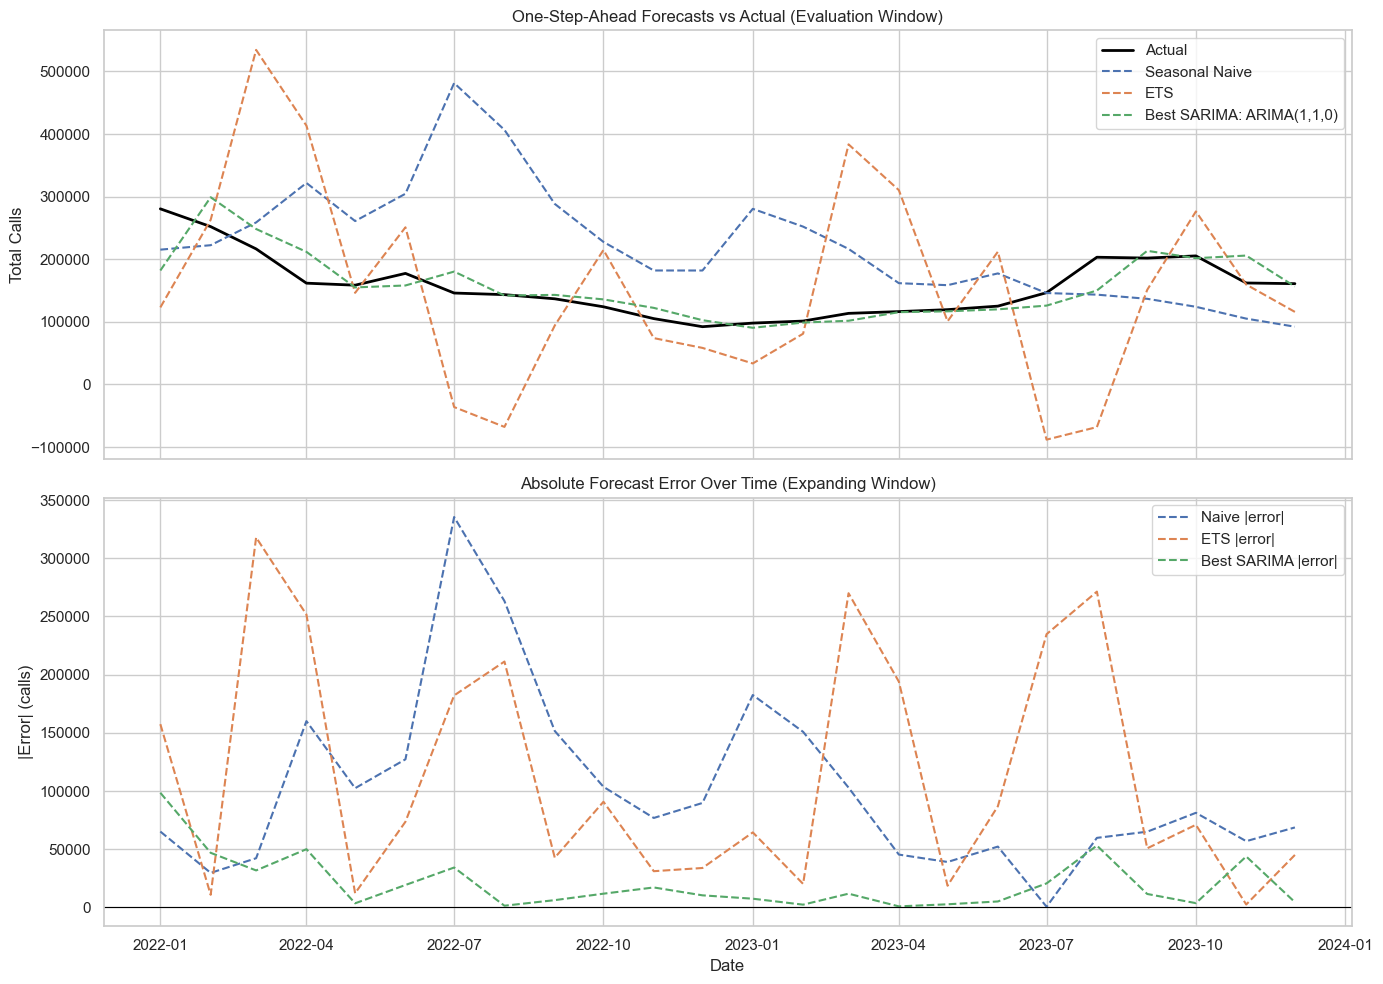

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: one-step-ahead forecasts vs actual
ax = axes[0]
ax.plot(y_eval.index, ew_naive["actual"],    label="Actual",         linewidth=2, color="black")
ax.plot(y_eval.index, ew_naive["forecast"],  label="Seasonal Naive", linestyle="--")
ax.plot(y_eval.index, ew_ets["forecast"],    label="ETS",            linestyle="--")
ax.plot(y_eval.index, best_sarima_eval_df["forecast"], label=f"Best SARIMA: {best_sarima_name}", linestyle="--")
ax.set_title("One-Step-Ahead Forecasts vs Actual (Evaluation Window)")
ax.set_ylabel("Total Calls")
ax.legend()

# Bottom panel: absolute error over time
ax2 = axes[1]
ax2.plot(y_eval.index, (ew_naive["actual"]  - ew_naive["forecast"]).abs(),  label="Naive |error|",  linestyle="--")
ax2.plot(y_eval.index, (ew_ets["actual"]    - ew_ets["forecast"]).abs(),    label="ETS |error|",    linestyle="--")
ax2.plot(y_eval.index, (best_sarima_eval_df["actual"] - best_sarima_eval_df["forecast"]).abs(), label="Best SARIMA |error|", linestyle="--")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Absolute Forecast Error Over Time (Expanding Window)")
ax2.set_xlabel("Date")
ax2.set_ylabel("|Error| (calls)")
ax2.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "expanding_window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Refit Best Model on All Pre-Test Data and Evaluate on Held-Out Test

Now that we have selected the best model using the expanding window,
we refit it on all data up to the end of the evaluation period (2016-04 to 2023-12)
and evaluate once on the held-out test set (2024-01 to 2025-02).

In [14]:
# Final refit using training + evaluation period
y_train_val_raw = y_raw.loc[:eval_end]
y_test_raw = y_raw.loc[test_start:]

if best_model_name == "SeasonalNaive(12)":
    history = y_train_val_raw.copy()
    preds = []

    for dt in y_test_raw.index:
        ref_date = dt - pd.DateOffset(months=12)
        pred = history.loc[ref_date] if ref_date in history.index else history.iloc[-1]

        preds.append(pred)
        history.loc[dt] = y_test_raw.loc[dt]

    y_pred_test = pd.Series(preds, index=y_test_raw.index, name="best_model_forecast")

elif best_model_name == "ETS_Additive":
    best_fit = ExponentialSmoothing(
        y_train_val_raw,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated"
    ).fit(optimized=True)

    y_pred_test = best_fit.forecast(len(y_test_raw))
    y_pred_test.index = y_test_raw.index
    y_pred_test.name = "best_model_forecast"

else:
    y_train_val_log = np.log1p(y_train_val_raw)

    best_fit = SARIMAX(
        y_train_val_log,
        order=best_sarima_order,
        seasonal_order=best_sarima_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    y_fc_log = best_fit.get_forecast(steps=len(y_test_raw)).predicted_mean

    y_pred_test = pd.Series(
        np.expm1(y_fc_log.values),
        index=y_test_raw.index,
        name="best_model_forecast"
    )

test_metrics_df = evaluate_forecast(
    y_test_raw,
    y_pred_test,
    f"{best_model_name}_TEST"
)

display(test_metrics_df)

,model,MAE,RMSE,MAPE_%,SMAPE_%
0,"ARIMA(1,1,0)_TEST",15871.1,21736.9,9.92,9.8


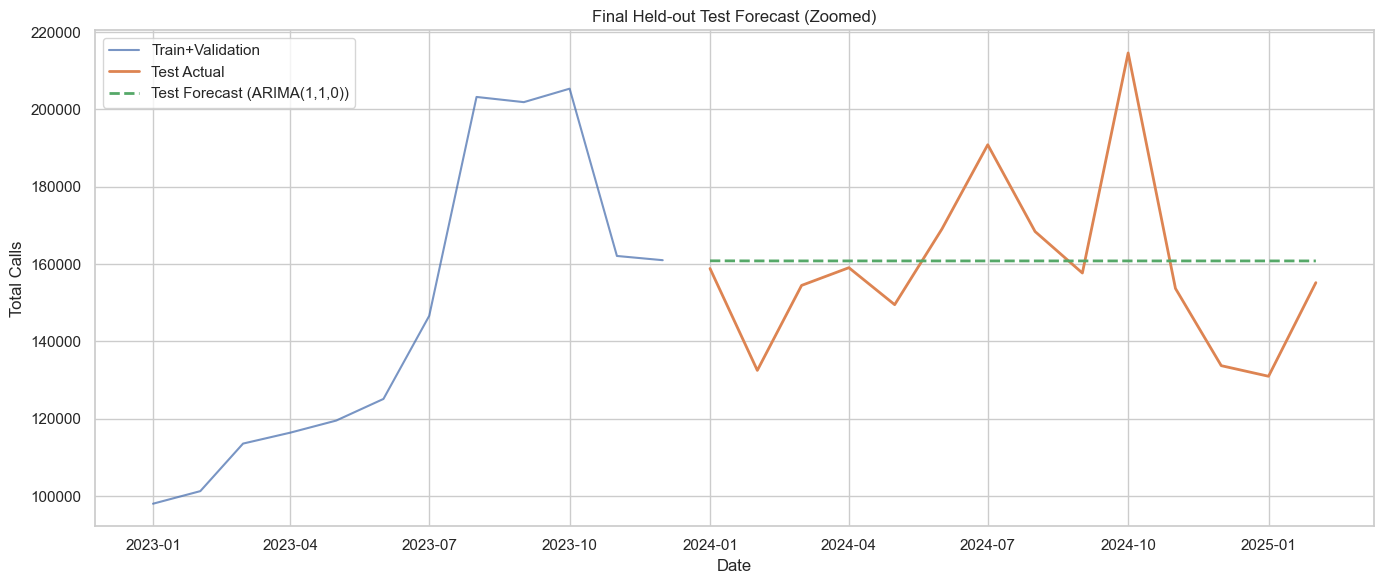

Saved plot: /Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/reports/figures/final_test_forecast_zoomed.png


In [ ]:
# Zoomed-in plot of test forecasts vs actuals
zoom_start = "2023-01-01"

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    y_train_val_raw.loc[zoom_start:].index,
    y_train_val_raw.loc[zoom_start:].values,
    label="Train+Validation",
    alpha=0.75
)

ax.plot(
    y_test_raw.index,
    y_test_raw.values,
    label="Test Actual",
    linewidth=2
)

ax.plot(
    y_pred_test.index,
    y_pred_test.values,
    label=f"Test Forecast ({best_model_name})",
    linestyle="--",
    linewidth=2
)

ax.set_title("Final Held-Out Test Forecast (Zoomed)")
ax.set_xlabel("Date")
ax.set_ylabel("Total Calls")
ax.legend()

plt.tight_layout()

plot_path = FIGURES_DIR / "final_test_forecast_zoomed.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

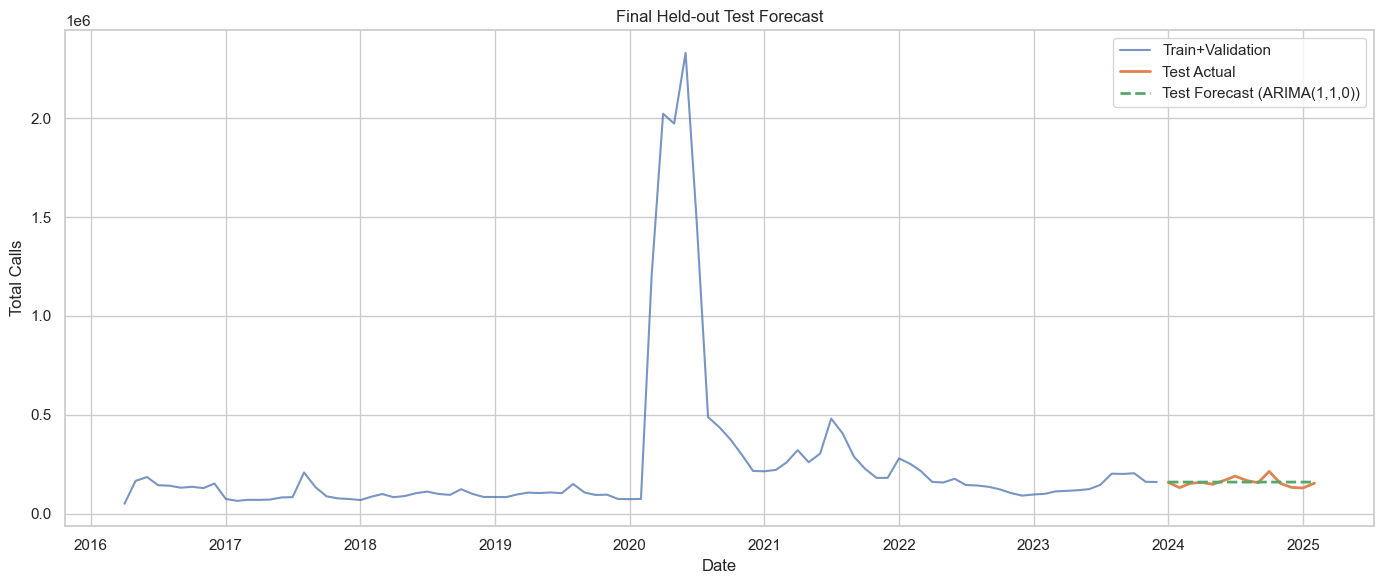

Saved plot: /Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/reports/figures/final_test_forecast.png


In [16]:
# Full-range plot of test forecasts vs actuals

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    y_train_val_raw.index,
    y_train_val_raw.values,
    label="Train+Validation",
    alpha=0.75
)

ax.plot(
    y_test_raw.index,
    y_test_raw.values,
    label="Test Actual",
    linewidth=2
)

ax.plot(
    y_pred_test.index,
    y_pred_test.values,
    label=f"Test Forecast ({best_model_name})",
    linestyle="--",
    linewidth=2
)

ax.set_title("Final Held-out Test Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Total Calls")
ax.legend()

plt.tight_layout()

plot_path = FIGURES_DIR / "final_test_forecast.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot: {plot_path}")

## 6. Save Artifacts

In [17]:
val_metrics_path = MODELS_DIR / "validation_metrics.csv"
test_metrics_path = MODELS_DIR / "test_metrics.csv"
forecast_path = MODELS_DIR / "final_test_forecasts.csv"

metrics_val_df.to_csv(val_metrics_path, index=False)
test_metrics_df.to_csv(test_metrics_path, index=False)
pd.DataFrame({
    "actual": y_test_raw, 
    "forecast": y_pred_test
    }).to_csv(forecast_path, index=True)

print("Saved artifacts:")
print(f"- {val_metrics_path}")
print(f"- {test_metrics_path}")
print(f"- {forecast_path}")

Saved artifacts:
- /Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/models/validation_metrics.csv
- /Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/models/test_metrics.csv
- /Users/Allison/Code/data_science_projects/healthcare-demand-forecasting-bd/models/final_test_forecasts.csv
